# Croma Laptop Price Analysis — Exploratory Data Analysis

**Objective:** Analyze 300+ laptop listings scraped from Croma.com to understand pricing patterns across brands, RAM/storage configurations, and processor types, and identify the best-value laptops in the market.

**Dataset:** Raw scraped listings (`Cromaaaa.xls`) — Brand, Model, RAM, SSD, Processor, Generation, Price

**Author:** Venkatesh Pola


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)


## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv('Cromaaaa.xls', sep='\t', encoding='utf-8')
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (309, 7)


,Brand,Model,RAM,SSD,Processor,Generation,Price
0,ASUS,Vivobook 16 X1605VA-MB1627WS,16.0,512.0,Intel Core i5,13th Gen,"? 72,990.00"
1,ASUS,TUF A15 FA506NCG-HN251WS,16.0,1000.0,AMD Ryzen 7,NaN,"? 85,990.00"
2,ASUS,Vivobook 14 Flip,16.0,512.0,Intel Core Ultra 5,NaN,"? 96,990.00"
3,Lenovo,LOQ 15IRX9 Intel,16.0,512.0,Intel Core i7,13th Gen,"? 109,990.00"
4,Asus,TUF A15 AMD,16.0,512.0,AMD Ryzen 7,NaN,"? 83,990.00"


## 2. Initial Data Quality Check

Before any analysis, we check for the usual real-world scraping issues: missing values, duplicates, inconsistent text formatting, and price stored as a currency string rather than a number.

In [3]:
print("Missing values per column:")
print(df_raw.isna().sum())
print()
print("Fully blank rows:", df_raw.isna().all(axis=1).sum())
print("Exact duplicate rows:", df_raw.duplicated().sum())
print()
print("Brand value inconsistencies:")
print(sorted(df_raw['Brand'].dropna().astype(str).unique()))
print()
print("Sample raw Price values:", df_raw['Price'].dropna().head(5).tolist())


Missing values per column:
Brand           1
Model           1
RAM             1
SSD            37
Processor      94
Generation    224
Price           6
dtype: int64

Fully blank rows: 1
Exact duplicate rows: 20

Brand value inconsistencies:
['ASUS', 'Acer', 'Apple', 'Asus', 'DELL', 'Dell', 'HP', 'Lenovo', 'MSI', 'Microsoft', 'SAMSUNG', 'acer']

Sample raw Price values: ['? 72,990.00', '? 85,990.00', '? 96,990.00', '? 109,990.00', '? 83,990.00']


**Findings:**
- Brand names are inconsistently cased (`ASUS` vs `Asus` vs `asus`, `DELL` vs `Dell`)
- `Price` is stored as text with a broken currency symbol and thousands separators (e.g. `"? 72,990.00"`)
- `SSD`, `Processor`, and `Generation` have missing values — expected for Apple/Qualcomm-based laptops, which don't use "generation" labeling
- 20 exact duplicate rows and 1 fully blank row need to be dropped

## 3. Data Cleaning

In [4]:
df = df_raw.dropna(how='all').reset_index(drop=True)

# Standardize brand casing
def fix_brand(x):
    x = str(x).strip()
    if x.upper() in ['ASUS', 'HP', 'MSI', 'DELL']:
        return x.upper()
    return x.title()

df['Brand'] = df['Brand'].apply(fix_brand)

# Clean Price: strip currency symbol/commas, convert to numeric
def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = re.sub(r'[^\d.]', '', str(x))
    try:
        return float(x)
    except ValueError:
        return np.nan

df['Price'] = df['Price'].apply(clean_price)

# Numeric conversions
df['RAM'] = pd.to_numeric(df['RAM'], errors='coerce')
df['SSD'] = pd.to_numeric(df['SSD'], errors='coerce')

# Handle missing categorical values
df['Processor'] = df['Processor'].fillna('Not Specified').str.strip()
df['Generation'] = df['Generation'].fillna('Not Specified').str.strip()

# SSD: impute missing with median (a handful of listings omit storage)
df['SSD'] = df['SSD'].fillna(df['SSD'].median())

# Feature engineering: processor brand family
def proc_brand(p):
    p = p.lower()
    if 'intel' in p: return 'Intel'
    if 'amd' in p: return 'AMD'
    if 'apple' in p: return 'Apple Silicon'
    if 'qualcomm' in p or 'snapdragon' in p: return 'Qualcomm'
    return 'Not Specified'

df['Processor_Brand'] = df['Processor'].apply(proc_brand)

# Value metric
df['Price_per_GB_RAM'] = (df['Price'] / df['RAM']).round(0)

# Drop duplicates and rows with no price (can't be analyzed on the price axis)
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
dupes_removed = before - len(df)

before_price = len(df)
df = df.dropna(subset=['Price']).reset_index(drop=True)
price_dropped = before_price - len(df)

print(f"Duplicates removed: {dupes_removed}")
print(f"Rows dropped for missing price: {price_dropped}")
print(f"Final clean dataset: {df.shape[0]} rows, {df.shape[1]} columns")


Duplicates removed: 20
Rows dropped for missing price: 4
Final clean dataset: 284 rows, 9 columns


In [5]:
df.to_csv('croma_laptops_clean.csv', index=False)
df.head()


,Brand,Model,RAM,SSD,Processor,Generation,Price,Processor_Brand,Price_per_GB_RAM
0,ASUS,Vivobook 16 X1605VA-MB1627WS,16.0,512.0,Intel Core i5,13th Gen,72990.0,Intel,4562.0
1,ASUS,TUF A15 FA506NCG-HN251WS,16.0,1000.0,AMD Ryzen 7,Not Specified,85990.0,AMD,5374.0
2,ASUS,Vivobook 14 Flip,16.0,512.0,Intel Core Ultra 5,Not Specified,96990.0,Intel,6062.0
3,Lenovo,LOQ 15IRX9 Intel,16.0,512.0,Intel Core i7,13th Gen,109990.0,Intel,6874.0
4,ASUS,TUF A15 AMD,16.0,512.0,AMD Ryzen 7,Not Specified,83990.0,AMD,5249.0


## 4. Descriptive Statistics

In [6]:
df[['RAM', 'SSD', 'Price']].describe().round(0)


,RAM,SSD,Price
count,284.0,284.0,284.0
mean,18.0,684.0,124800.0
std,10.0,291.0,71642.0
min,8.0,256.0,40990.0
25%,16.0,512.0,73990.0
50%,16.0,512.0,104994.0
75%,16.0,1000.0,155115.0
max,128.0,2000.0,500990.0


In [7]:
df['Brand'].value_counts()


Brand
Lenovo       66
ASUS         59
HP           56
DELL         23
Acer         23
Samsung      21
Apple        13
Microsoft    13
MSI          10
Name: count, dtype: int64

## 5. Univariate Analysis

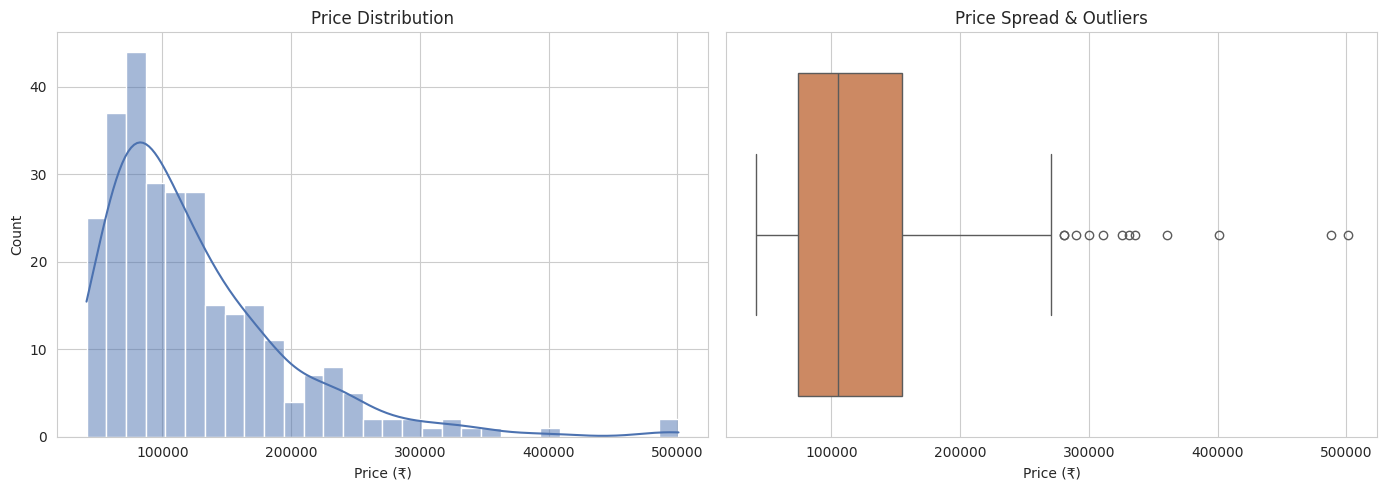

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price'], bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (₹)')

sns.boxplot(x=df['Price'], ax=axes[1], color='#DD8452')
axes[1].set_title('Price Spread & Outliers')
axes[1].set_xlabel('Price (₹)')

plt.tight_layout()
plt.show()


Price is right-skewed — most laptops cluster between ₹50K–₹150K, with a long tail of premium/gaming laptops pulling the mean above the median. The boxplot outliers above ~₹300K are legitimate flagship gaming/workstation laptops (e.g. ASUS ROG Strix SCAR, Lenovo Legion Pro 7), not data errors.

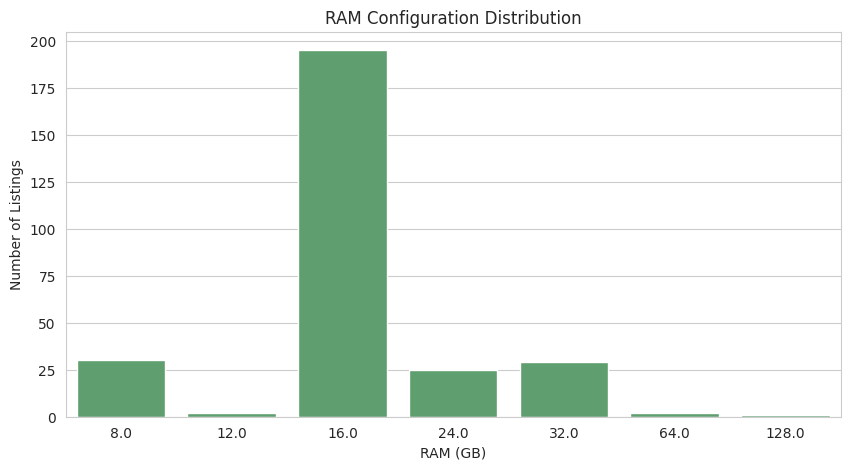

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='RAM', order=sorted(df['RAM'].unique()), color='#55A868')
plt.title('RAM Configuration Distribution')
plt.xlabel('RAM (GB)')
plt.ylabel('Number of Listings')
plt.show()


16GB is the dominant configuration (roughly two-thirds of listings), confirming it's the current market standard rather than a premium tier. 8GB laptops represent the budget segment; 32GB+ marks gaming/workstation-class machines.

## 6. Price by Brand

/tmp/ipykernel_627/978903907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Brand', y='Price', order=order, estimator=np.mean, errorbar=None, palette='viridis')


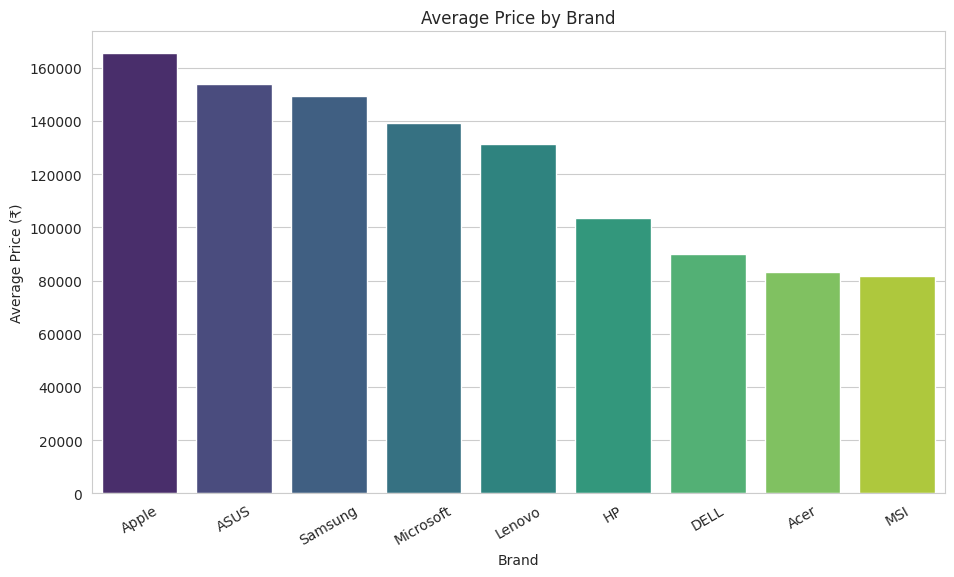

In [10]:
order = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).index
plt.figure(figsize=(11, 6))
sns.barplot(data=df, x='Brand', y='Price', order=order, estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Average Price by Brand')
plt.ylabel('Average Price (₹)')
plt.xticks(rotation=30)
plt.show()


In [11]:
df.groupby('Brand')['Price'].agg(['mean','median','count']).round(0).sort_values('mean', ascending=False)


,mean,median,count
Brand,,,
Apple,165362.0,151900.0,13
ASUS,153716.0,109990.0,59
Samsung,149538.0,138990.0,21
Microsoft,139304.0,134990.0,13
Lenovo,131428.0,115490.0,66
HP,103512.0,90490.0,56
DELL,89930.0,73990.0,23
Acer,83382.0,77490.0,23
MSI,81590.0,79490.0,10


Apple, ASUS, and Samsung carry the highest average prices. ASUS's premium is driven largely by its ROG gaming line rather than a blanket brand markup — worth noting when comparing brand positioning. MSI and Acer sit at the value end of the market.

## 7. Price by Processor Brand

/tmp/ipykernel_627/3746815545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Processor_Brand', y='Price', palette='Set2')


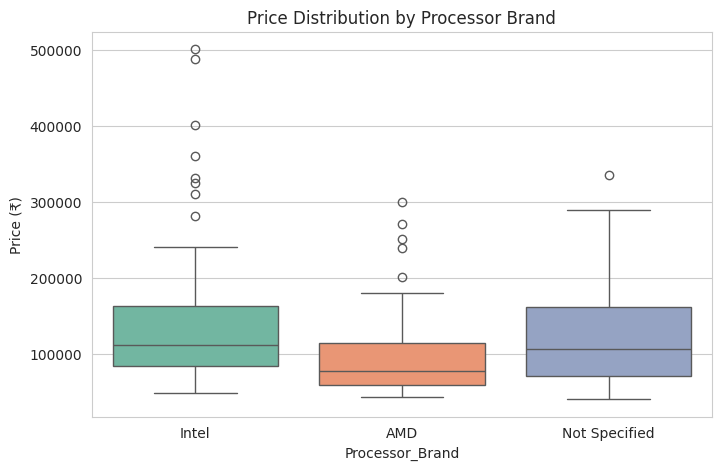

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Processor_Brand', y='Price', palette='Set2')
plt.title('Price Distribution by Processor Brand')
plt.ylabel('Price (₹)')
plt.show()


In [13]:
df.groupby('Processor_Brand')['Price'].mean().round(0).sort_values(ascending=False)


Processor_Brand
Intel            133904.0
Not Specified    125805.0
AMD               99015.0
Name: Price, dtype: float64

Intel-powered laptops average roughly ₹35K more than AMD equivalents in this dataset. This doesn't necessarily mean Intel is "better" — it likely reflects which OEMs and product tiers pair with which chipmaker (e.g. more premium ultrabooks ship with Intel, more budget/mid-range gaming laptops ship with AMD Ryzen).

## 8. RAM & SSD vs Price

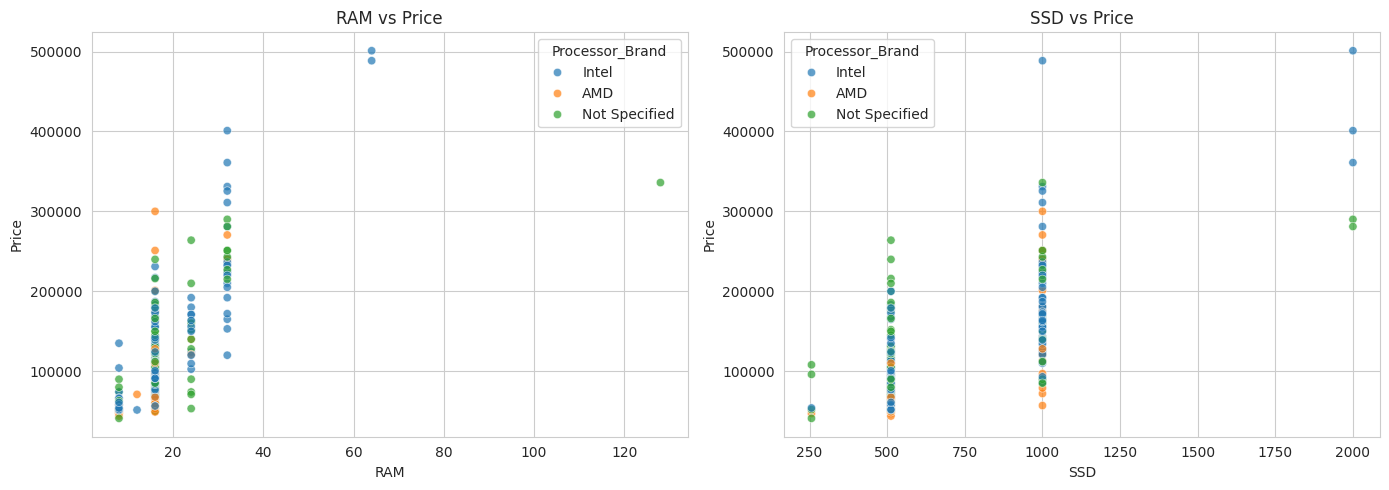

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='RAM', y='Price', hue='Processor_Brand', alpha=0.7, ax=axes[0])
axes[0].set_title('RAM vs Price')

sns.scatterplot(data=df, x='SSD', y='Price', hue='Processor_Brand', alpha=0.7, ax=axes[1])
axes[1].set_title('SSD vs Price')

plt.tight_layout()
plt.show()


In [15]:
df[['RAM','SSD','Price']].corr()['Price'].round(2)


RAM      0.68
SSD      0.68
Price    1.00
Name: Price, dtype: float64

Both RAM and SSD show a moderate-to-strong positive correlation with price (~0.68 each), as expected. Neither alone fully explains price — brand and processor tier matter too, which is why a multi-factor view (rather than a single scatter) is needed in the dashboard.

## 9. Business Questions

In [16]:
print("Top 5 most expensive laptops:")
df.nlargest(5, 'Price')[['Brand','Model','RAM','SSD','Price']]


Top 5 most expensive laptops:


,Brand,Model,RAM,SSD,Price
222,ASUS,ROG Strix SCAR,64.0,2000.0,500990.0
257,Lenovo,Legion Pro 7,64.0,1000.0,488490.0
86,ASUS,ROG Strix SCAR,32.0,2000.0,400990.0
230,ASUS,ROG Zephyrus G16,32.0,2000.0,360990.0
276,ASUS,ProArt PX13 HN7306EAC-LX052WS,128.0,1000.0,335990.0


In [17]:
print("Best value laptops (lowest price per GB RAM, 16GB+ only):")
df[df['RAM'] >= 16].nsmallest(5, 'Price_per_GB_RAM')[['Brand','Model','RAM','Price','Price_per_GB_RAM']]


Best value laptops (lowest price per GB RAM, 16GB+ only):


,Brand,Model,RAM,Price,Price_per_GB_RAM
206,HP,15-fd0886TU Intel Core,24.0,53190.0,2216.0
276,ASUS,ProArt PX13 HN7306EAC-LX052WS,128.0,335990.0,2625.0
190,HP,15-hr0124TU Intel Core,24.0,70999.0,2958.0
212,ASUS,Vivobook Go 15,16.0,48994.0,3062.0
122,HP,15-fd0901TU Intel Core,24.0,73990.0,3083.0


## 10. Key Findings Summary

1. **16GB RAM is the market standard** — not a premium differentiator anymore. Any competitive pricing strategy should treat 16GB as the baseline, not an upsell.
2. **AMD Ryzen is the value play in this market** — Intel-equipped laptops average ~₹35K more, largely due to product-tier mix rather than raw chip pricing.
3. **Brand premium is uneven** — ASUS spans both budget (Vivobook) and ultra-premium (ROG Strix, up to ₹5L) segments, so "ASUS is expensive" is only true once you control for product line.
4. **RAM and storage explain roughly 46% of price variance** (R² from the ~0.68 correlation) — the rest comes down to brand, processor tier, and build quality, which a simple spec-based pricing model would miss.
5. **HP and budget ASUS models offer the best price-per-GB-RAM value** among 16GB+ configurations — useful for a "best value" recommendation engine or comparison shopping feature.

**Recommendation:** If Croma wanted to optimize its budget laptop assortment, the data suggests doubling down on 16GB/512GB AMD Ryzen configurations from HP and ASUS — they hit the sweet spot of current market standard specs at the lowest price-per-GB benchmark.
